In [1]:
!pip install dash
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from dash import Dash, dcc, html, Input, Output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 54.2 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/covid_19_clean_complete.csv")

In [3]:
df = df[['Date',
         'Country/Region',
         'Confirmed',
         'Deaths',
         'Recovered',
         'Active']]

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.fillna(0, inplace=True)

In [7]:
df['Confirmed'] = df['Confirmed'].clip(lower=0)
df['Deaths'] = df['Deaths'].clip(lower=0)
df['Recovered'] = df['Recovered'].clip(lower=0)
df['Active'] = df['Active'].clip(lower=0)

In [8]:
print("\nDataset Information")
print(df.info())


Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 47172 entries, 0 to 49067
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            47172 non-null  datetime64[ns]
 1   Country/Region  47172 non-null  object        
 2   Confirmed       47172 non-null  int64         
 3   Deaths          47172 non-null  int64         
 4   Recovered       47172 non-null  int64         
 5   Active          47172 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 2.5+ MB
None


In [9]:
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
Date              0
Country/Region    0
Confirmed         0
Deaths            0
Recovered         0
Active            0
dtype: int64


In [10]:
print("\nDescriptive Statistics")
print(df.describe())



Descriptive Statistics
                                Date     Confirmed         Deaths  \
count                          47172  4.717200e+04   47172.000000   
mean   2020-04-27 06:11:54.322055424  1.756355e+04     919.717248   
min              2020-01-22 00:00:00  0.000000e+00       0.000000   
25%              2020-03-13 00:00:00  8.000000e+00       0.000000   
50%              2020-04-28 00:00:00  1.930000e+02       3.000000   
75%              2020-06-12 00:00:00  1.661000e+03      35.000000   
max              2020-07-27 00:00:00  4.290259e+06  148011.000000   
std                              NaN  1.297875e+05    6436.680583   

          Recovered        Active  
count  4.717200e+04  4.717200e+04  
mean   8.233871e+03  8.409964e+03  
min    0.000000e+00  0.000000e+00  
25%    0.000000e+00  0.000000e+00  
50%    4.400000e+01  3.500000e+01  
75%    7.550000e+02  6.870000e+02  
max    1.846641e+06  2.816444e+06  
std    5.586797e+04  7.775882e+04  


In [11]:
total_confirmed = df['Confirmed'].sum()
total_deaths = df['Deaths'].sum()
total_recovered = df['Recovered'].sum()
total_active = df['Active'].sum()

print("\nTotal Confirmed Cases :", total_confirmed)
print("Total Deaths :", total_deaths)
print("Total Recovered :", total_recovered)
print("Total Active Cases :", total_active)


Total Confirmed Cases : 828507763
Total Deaths : 43384902
Total Recovered : 388408160
Total Active Cases : 396714817


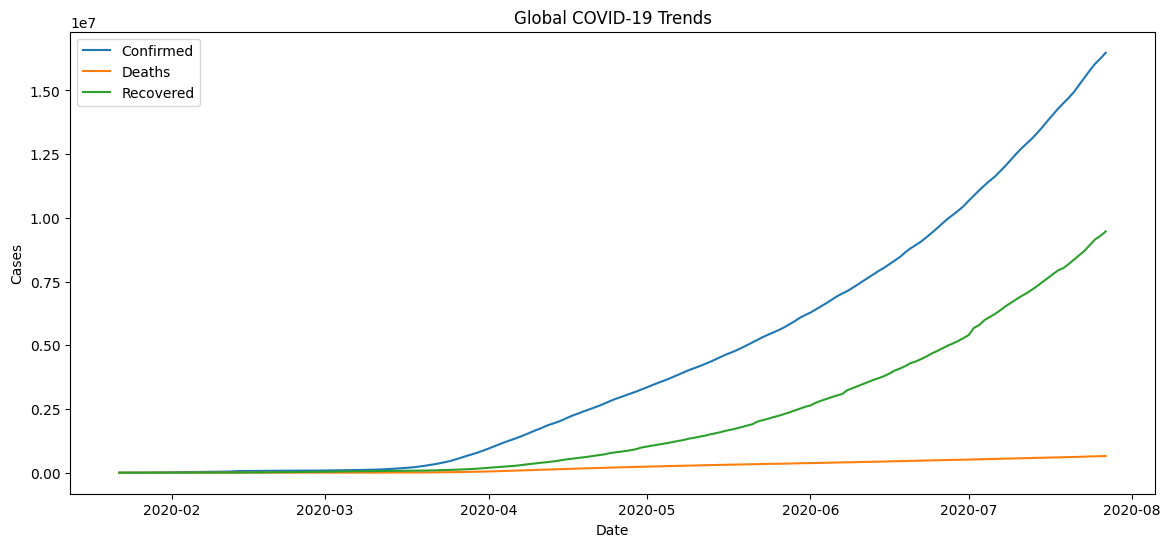

In [12]:
daily_cases = df.groupby('Date')[[
    'Confirmed',
    'Deaths',
    'Recovered',
    'Active'
]].sum().reset_index()

plt.figure(figsize=(14,6))

plt.plot(daily_cases['Date'],
         daily_cases['Confirmed'],
         label='Confirmed')

plt.plot(daily_cases['Date'],
         daily_cases['Deaths'],
         label='Deaths')

plt.plot(daily_cases['Date'],
         daily_cases['Recovered'],
         label='Recovered')

plt.title("Global COVID-19 Trends")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()

plt.show()

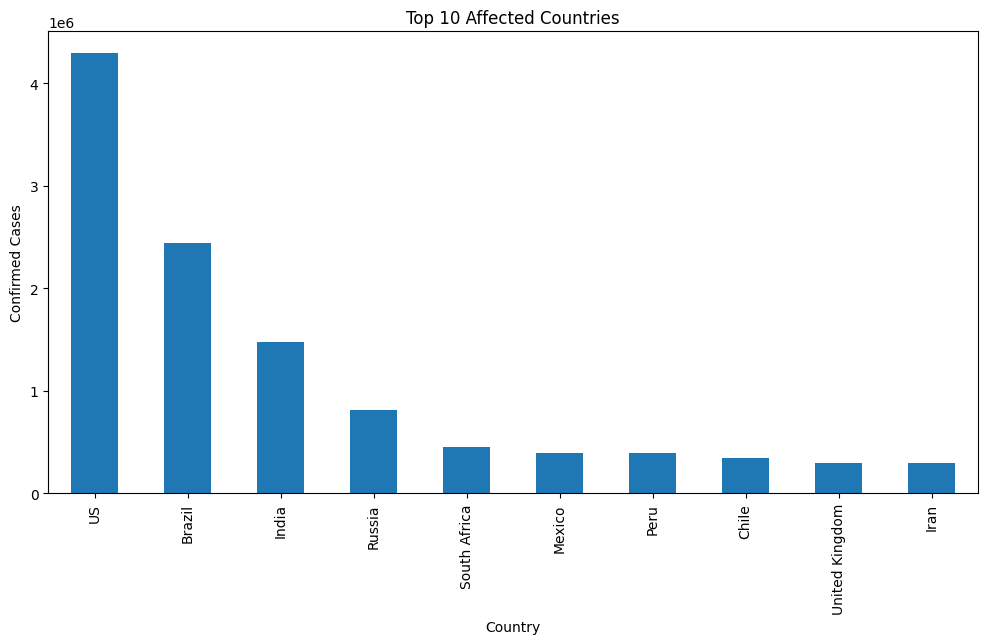

In [13]:

top_countries = df.groupby('Country/Region')['Confirmed'] \
                  .max() \
                  .sort_values(ascending=False) \
                  .head(10)

plt.figure(figsize=(12,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Affected Countries")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")

plt.show()


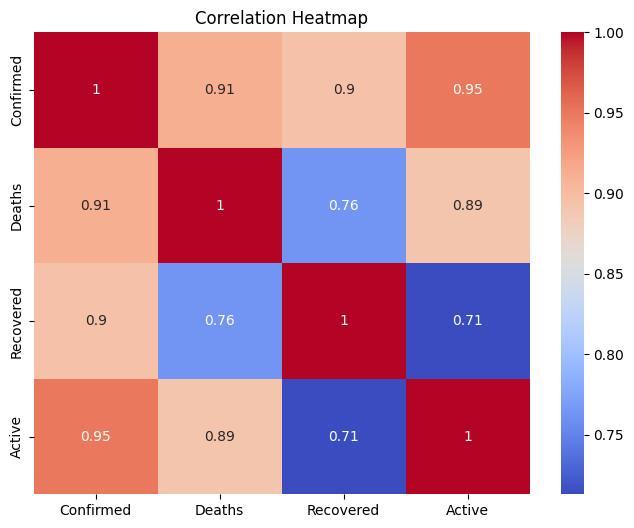

In [14]:
corr = df[['Confirmed',
           'Deaths',
           'Recovered',
           'Active']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()


In [15]:
fig = px.line(
    daily_cases,
    x='Date',
    y='Confirmed',
    title='Global Confirmed Cases Over Time'
)

fig.show()


In [16]:
top10 = df.groupby('Country/Region')['Confirmed'] \
          .max() \
          .sort_values(ascending=False) \
          .head(10) \
          .reset_index()

fig = px.bar(
    top10,
    x='Country/Region',
    y='Confirmed',
    title='Top 10 Affected Countries',
    color='Confirmed'
)

fig.show()

In [17]:
pie_df = pd.DataFrame({
    'Category': ['Confirmed',
                 'Deaths',
                 'Recovered',
                 'Active'],

    'Count': [total_confirmed,
              total_deaths,
              total_recovered,
              total_active]
})

fig = px.pie(
    pie_df,
    names='Category',
    values='Count',
    title='COVID-19 Case Distribution'
)

fig.show()


In [18]:
fig = px.scatter(
    df,
    x='Confirmed',
    y='Deaths',
    size='Recovered',
    color='Active',
    title='Confirmed vs Deaths'
)

fig.show()

In [19]:
app = Dash(__name__)
countries = df['Country/Region'].unique()
app.layout = html.Div([

    html.H1(
        "COVID-19 Dashboard",
        style={'textAlign': 'center'}
    ),

    html.Br(),

    html.Label("Select Country"),

    dcc.Dropdown(
        id='country-dropdown',
        options=[{'label': country, 'value': country}
                 for country in countries],
        value='India'
    ),

    html.Br(),

    # Line Chart
    dcc.Graph(id='line-chart'),

    html.Br(),

    # Bar Chart
    dcc.Graph(id='bar-chart'),

    html.Br(),

    # Scatter Plot
    dcc.Graph(id='scatter-chart')

])

In [20]:
@app.callback(
    [Output('line-chart', 'figure'),
     Output('bar-chart', 'figure'),
     Output('scatter-chart', 'figure')],

    [Input('country-dropdown', 'value')]
)

def update_dashboard(selected_country):

    # Filter country data
    filtered_df = df[df['Country/Region'] == selected_country]

    # Daily grouped data
    daily = filtered_df.groupby('Date')[[     'Confirmed',
     'Deaths',
     'Recovered',
     'Active'
 ]].sum().reset_index()

    # Line Chart
    line_fig = px.line(
        daily,
        x='Date',
        y=['Confirmed', 'Deaths', 'Recovered'],
        title=f'COVID-19 Trends in {selected_country}'
    )

    # Bar Chart
    bar_fig = px.bar(
        daily,
        x='Date',
        y='Confirmed',
        title=f'Confirmed Cases in {selected_country} Over Time'
    )

    # Scatter Plot
    scatter_fig = px.scatter(
        daily,
        x='Confirmed',
        y='Deaths',
        size='Recovered',
        color='Active',
        title=f'Confirmed vs. Deaths in {selected_country}'
    )

    return line_fig, bar_fig, scatter_fig

In [24]:
print("INSIGHTS:")

print("1. Countries with high confirmed cases have higher risk levels.")

print("2. There is a strong relationship between confirmed cases and deaths.")

print("3. Higher recovery numbers indicate improvement in healthcare systems.")

print("4. Active cases represent the current pandemic situation in each country.")

print("5. Data visualization helps understand trends and supports decision making.")


INSIGHTS:
1. Countries with high confirmed cases have higher risk levels.
2. There is a strong relationship between confirmed cases and deaths.
3. Higher recovery numbers indicate improvement in healthcare systems.
4. Active cases represent the current pandemic situation in each country.
5. Data visualization helps understand trends and supports decision making.
